The LSA Coherence method of Foltz et al. (1998) is one of the
first to use embeddings. It compute the coherence between two sentences as the cosine between their LSA sentence embedding vectors, computing embeddings for a sentence s by summing the embeddings of its words w. In this code I'll use this approach by using precomputed embeddings having a small amount of data.

The coherence of an entire text (or dialogue in this case) can be computed with the following formula: \\


$coherence(T) = \frac{1}{n-1} \sum_{i=1}^{n-1} \cos(s_i, s_{i+1})$

Since the training has been perfomed by making the llm give an answer to a prompt, without giving any context about the preciding utterancess, with the generated answers to the test set will be computed the coherence only between prompt and relative answer, not of the entire dialogue.

This kind of local coherence is the semantic coherence. It takes into account only the semantic similarity and it ignore discourse structure.

reference:https://web.stanford.edu/~jurafsky/slp3/24.pdf

In [76]:
#importing data
import pandas as pd
df = pd.read_csv("/content/LLM_test_with_generated.csv")

df.head()

,prompt,answer,generated
0,Hi.,You mind if I,Hey.
1,"No, please.","So uh, what are you in for?",Please.
2,I talk in my sleep.,"What a coincidence, I listen in my sleep.",Oh my God.
3,"And it’s not fake, it’s totally brutal.","Yeah, it’s two guys in a ring, and the rules a...","Okay, this is why we can’t have nice things."
4,"Oh, Bob, he was nothing compared to you. I had...","Well, that makes me feel so good.",Thats my girl.


In [77]:
#tranforming to list the columns of the dataframe
prompt=df["prompt"].to_list()
utt=df["answer"].to_list()
gen_utt=df["generated"].to_list()

In [78]:
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import word_tokenize, pos_tag

nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')


stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [79]:
lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):               #function used by nltk to properly lemmatize (without this it would consider every word as a noun and could make error in lemmatization)
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # default

def preprocess_text(text):
    # Tokenize the text
    tokenized_text_list = []
    for sent in text:
      tokenized_text = word_tokenize(sent)
      tagged = pos_tag(tokenized_text)
      # Remove punctuation and convert to lowercase
      tokens = [lemmatizer.lemmatize(word.lower(), get_wordnet_pos(pos)) for word,pos in tagged if word not in string.punctuation and word not in stop_words]
      tokenized_text_list.append(tokens)

    return tokenized_text_list

token_prompt=preprocess_text(prompt)
token_response=preprocess_text(utt)
token_llm=preprocess_text(gen_utt)


In [80]:
!pip install gensim

In [81]:
from gensim.models import KeyedVectors
model = KeyedVectors.load_word2vec_format('/content/drive/MyDrive/IR_NLP_2025_Shared/Angelo Gabriele Cusmano/wiki-news-300d-1M-subword.vec', limit=200000)

In [82]:
import numpy as np

def get_sentence_embedding(tokens, model):
    valid_vectors = [model[word] for word in tokens if word in model]
    if valid_vectors:
        return np.mean(valid_vectors, axis=0)
    else:
        return np.zeros(model.vector_size)
#importing the word2vec embedding for every word
emb_prompt = np.array([get_sentence_embedding(t, model) for t in token_prompt])
emb_response = np.array([get_sentence_embedding(t, model) for t in token_response])
emb_llm = np.array([get_sentence_embedding(t, model) for t in token_llm])

In [83]:
sim_reference=np.zeros(len(emb_prompt))
sim_llm=np.zeros(len(emb_prompt))

for i in range(len(emb_prompt)):
    sim_reference[i]=np.dot(emb_prompt[i],emb_response[i])/(np.linalg.norm(emb_prompt[i])*np.linalg.norm(emb_response[i]))
    sim_llm[i]=np.dot(emb_prompt[i],emb_llm[i])/(np.linalg.norm(emb_prompt[i])*np.linalg.norm(emb_llm[i]))

Comparison of Similarities:


,Prompt,Reference_Similarity,LLM_Similarity
0,Hi.,0.410620,0.604112
1,"No, please.",0.484849,0.586568
2,I talk in my sleep.,0.954104,0.273499
3,"And it’s not fake, it’s totally brutal.",0.956654,0.941581
4,"Oh, Bob, he was nothing compared to you. I had...",0.542680,0.385679
...,...,...,...
261,"Oh, my mom called, they’re gonna run our engag...",0.871607,0.448507
262,"That’s not true, there are great pictures of us!",0.681040,0.118400
263,Oh my God! That’s the creep that you’re with a...,0.870781,0.221634
264,"Oh, here’s a great one.",0.827633,0.329301



Descriptive Statistics of Similarities:
       Reference_Similarity  LLM_Similarity
count            262.000000      253.000000
mean               0.531791        0.517961
std                0.248046        0.223706
min               -0.037223        0.081586
25%                0.348518        0.356864
50%                0.531195        0.509750
75%                0.709741        0.657447
max                1.000000        1.000000


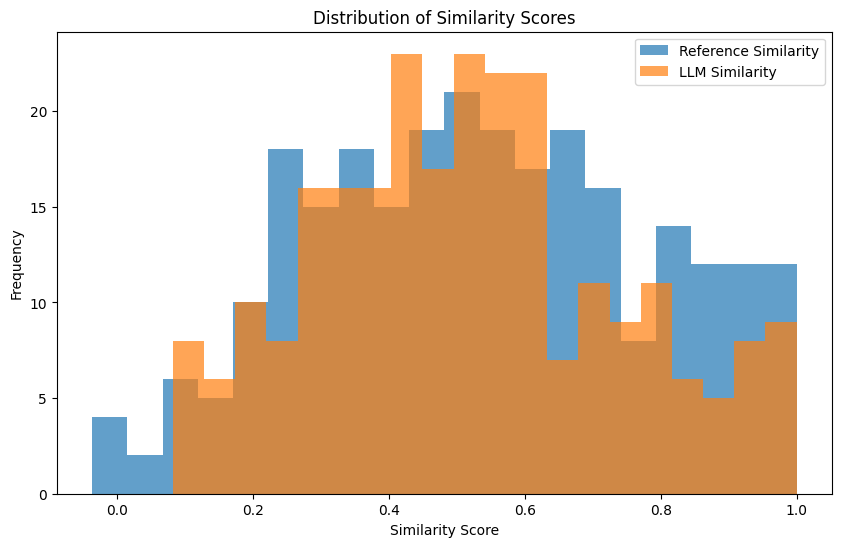

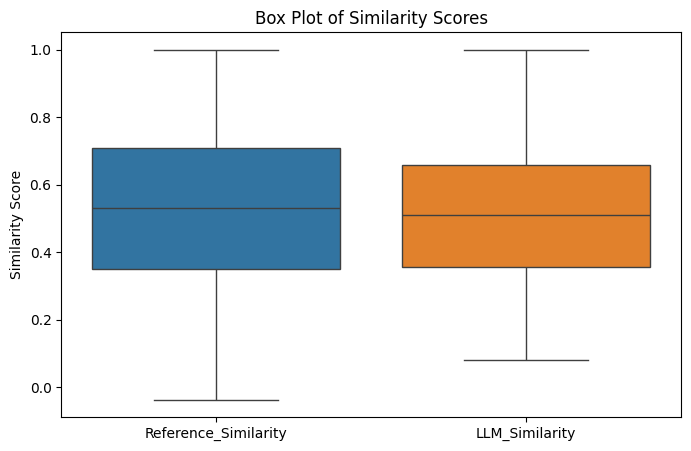

In [84]:
import pandas as pd
# Create a new DataFrame to compare the similarities
comparison_df = pd.DataFrame({
    'Prompt': prompt,
    'Reference_Similarity': sim_reference,
    'LLM_Similarity': sim_llm
})

print("Comparison of Similarities:")
display(comparison_df)

# Calculate and print descriptive statistics for the similarities
print("\nDescriptive Statistics of Similarities:")
print(comparison_df[['Reference_Similarity', 'LLM_Similarity']].describe())


import matplotlib.pyplot as plt

#distribution of similarity score

plt.figure(figsize=(10, 6))
plt.hist(comparison_df['Reference_Similarity'], bins=20, alpha=0.7, label='Reference Similarity')
plt.hist(comparison_df['LLM_Similarity'], bins=20, alpha=0.7, label='LLM Similarity')
plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of Similarity Scores')
plt.legend()
plt.show()


#!pip install seaborn
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.boxplot(data=comparison_df[['Reference_Similarity', 'LLM_Similarity']])
plt.ylabel('Similarity Score')
plt.title('Box Plot of Similarity Scores')
plt.show()


In [85]:
dialogue = [
    "Hey, how's it going?",
    "Hey! I'm doing well—thanks for asking. How about you?",
    "Want to catch a movie?",
    "No! Do we have to sit together?",
    "Yes if we want to watch it",
    "I've never sat with girls before.",
    "It's fine, no prob, I'm not a girl!",
    "You're a guy. You can do whatever you want.",
    "That sounds weird",
    "Well, you're gonna buy the first ticket.",
    "Ok, so we'll go to the cinema?",
    "No! Do we have to sit together?",
    "Yes",
    "Do we have to sit together?",
    "yes",
    "Oh-ho. You're really hard to buy a ticket from, aren't you?",
    "It makes no sense",
    "You're not buying me a ticket. I'm gonna buy my own ticket.",
    "No no. I'll buy a ticket to you",
    "Do we have to sit together?  I've never sat with guys before, and you're gonna buy tickets to me? What's wrong with you?"
]


In [86]:
token_dialogue=preprocess_text(dialogue)
emb_dialogue = np.array([get_sentence_embedding(tokens, model) for tokens in token_dialogue])

In [87]:
coherence=0

for j in range(len(emb_dialogue)-1):
  coherence+=np.dot(emb_dialogue[j],emb_dialogue[j+1])/((np.linalg.norm(emb_dialogue[j])*np.linalg.norm(emb_dialogue[j+1])))

coherence/=(len(emb_dialogue)-1)

In [88]:
print(coherence)

0.6515501565054843


In [ ]:
#CHATGPT generated dialogue

dialogue_ref = [
    "Ehi, hai voglia di fare una gita al lago questo fine settimana?",
    "Sì, mi sembra un’ottima idea! Il lago è perfetto per rilassarsi.",
    "Potremmo portare dei panini e fare un picnic sulla riva.",
    "Ottimo, e magari dopo il pranzo possiamo anche fare un giro in pedalò.",
    "Sì, adoro andare in pedalò, soprattutto quando il tempo è bello.",
    "Le previsioni dicono che sabato ci sarà il sole tutto il giorno.",
    "Perfetto, allora possiamo anche prendere il telo e sdraiarci a prendere il sole.",
    "Già, portiamo anche la crema solare, non voglio scottarmi come l’ultima volta.",
    "Hai ragione, e magari mettiamo qualche bibita fresca nella borsa frigo.",
    "Ottima idea! Con qualcosa di fresco sarà ancora più piacevole."
]



In [102]:
token_dialogue_ref=preprocess_text(dialogue_ref)
emb_dialogue_ref=np.array([get_sentence_embedding(tokens, model) for tokens in token_dialogue_ref])

In [104]:
coherence_ref = 0

for j in range(len(emb_dialogue_ref)-1):
  coherence_ref += np.dot(emb_dialogue_ref[j], emb_dialogue_ref[j+1]) / ((np.linalg.norm(emb_dialogue_ref[j]) * np.linalg.norm(emb_dialogue_ref[j+1])))

coherence_ref /= (len(emb_dialogue_ref)-1)

print("Coherence of GPT dialogue:", coherence_ref)

Coherence of GPT dialogue: 0.6296129656525759
